In [3]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

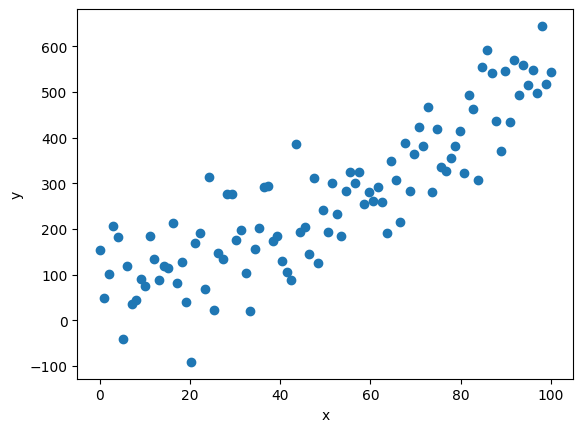

In [5]:
np.random.seed(0)
X = np.linspace(0, 100, 100)
y = 5 * X + 12
ny = np.random.normal(scale = 80, size = y.shape[0]) + y

data = pd.DataFrame({'x' : X, 'ny' : ny}).sample(frac = 1).reset_index(drop = True)
plt.scatter(X, ny)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [28]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.3, random_state = 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state = 42)

print(f"Train set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

Train set size: 70
Validation set size: 15
Test set size: 15


Why Split the Data?
Train Set: Helps the model learn.
Validation Set: Acts like a "checkpoint" during training to assess how well the model generalizes. This ensures the model doesn't just memorize the training data.
Test Set: Provides an unbiased evaluation of the final model.

Common splitting ratios:
Train : Validation : Test = 60 : 20 : 20
Train : Validation : Test = 70 : 15 : 15
Ratios depend on the dataset size. Larger datasets can have smaller test/validation splits.

Bias and Variance
=================
What is Bias?
=============
Definition: Bias is the difference between the average prediction of a machine learning model and the true value we are trying to predict. It measures how much the model's predictions deviate from the actual target values.

Cause: High bias typically occurs when a model is too simple to capture the underlying structure of the data.

Effect: Models with high bias often underfit the data, leading to poor performance on both training and test datasets.

Underfitting happens when the model is too simple and cannot learn the patterns in the training data.

Example: Trying to fit a linear regression model to a dataset where the relationship between features is nonlinear.

Example of High Bias:
_____________________
Let’s consider a real-world example of predicting house prices:

Dataset: Houses with features like square footage, number of bedrooms, location, etc.

Target: Predict the house price.

Scenario: You use a linear regression model with only one feature (square footage).

    The model assumes house price depends solely on square footage and ignores other important factors.
    
    Result: The model will fail to capture the complex relationship between all features and house price, leading to underfitting and a high error rate.


Best Ways to Handle Underfitting:
==================================
Underfitting occurs when the model is too simple to capture the data's complexity.

1- Use a more complex model (e.g., move from linear to polynomial regression, or use deeper neural networks).

2- Add more relevant features or perform better feature engineering.

3- Reduce regularization (e.g., decrease lambda in L2 regularization or dropout rate in neural networks).

4- Train the model longer (increase epochs or iterations).
Tune hyperparameters (e.g., learning rate, tree depth, or number of neurons).
____________________________________________________________________________
What is Variance?
=================
Definition: Variance is the variability of a model's predictions for a given data point. It measures how much the predictions change if the training data changes.

Cause: High variance typically occurs when a model is too complex and captures the noise in the training data rather than the actual pattern.

Effect: Models with high variance perform very well on training data but fail to generalize on unseen (test) data, leading to overfitting.

1- Noise in the dataset:

    High-variance models tend to learn not only the underlying pattern but also the random noise in the data.

    Example: A dataset has outliers, and the model adjusts to them unnecessarily, impacting its generalization ability.

Example of High Variance:
_________________________
Let’s consider the same house price prediction scenario:

Dataset: Houses with features like square footage, number of bedrooms, and location.

Target: Predict house prices.

Scenario: You use a model with a very high degree polynomial to fit the training data.

    The model learns the exact relationship of the training data, including noise and outliers, creating a highly complex curve.

    Result: The model gives excellent predictions for training data but performs poorly on unseen data, as it does not generalize well.

Best Ways to Handle Overfitting
===============================
Overfitting occurs when the model learns the noise instead of the underlying patterns.

1- Simplify the model (e.g., reduce tree depth or the number of neurons).

2- Add regularization (e.g., L1/L2 regularization, dropout for neural networks).

3- Increase training data (to generalize better).

4- Early stopping (stop training when validation error stops improving).

5- Use cross-validation (e.g., k-fold CV to avoid overfitting to a specific dataset).

6- Prune features or handle outliers if they distort the model.

____________________________________________________________________________

Ideal Scenario is to reach to (Low Bias + Low Variance)

In [30]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [63]:
X_train_pred = model.predict(X_train)
X_val_pred   = model.predict(X_val)
X_test_pred  = model.predict(X_test)

In [67]:
training_mse = mean_squared_error(y_train, X_train_pred)
val_mse = mean_squared_error(y_train, X_train_pred)
test_mse = mean_squared_error(y_test, X_test_pred)

In [68]:
print(f"training_mse: {training_mse}")
print(f"val_mse: {val_mse}")
print(f"test_mse: {test_mse}")

training_mse: 0.4119996108951729
val_mse: 0.4119996108951729
test_mse: 0.4958877701661202


To prevent overfitting, we add a regularization term to the loss function. The regularization term discourages large values of the coefficients β, which might cause overfitting. The two types of regularization are:

1- Ridge Regression (L2 Regularization): Adds the sum of the squared coefficients as a penalty term.

$$
J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{m} \beta_j^2
$$

Where:

$(\lambda)$ is the regularization parameter (controls the strength of regularization)<br>
$(\beta_j)$ are the coefficients for each feature.<br>

2-Lasso Regression (L1 Regularization): Adds the sum of the absolute values of the coefficients as a penalty term.

$$
J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{m} |\beta_j|
$$

Where:

$(\lambda)$ is the regularization parameter.

---

### ***Ridge Regression (L2 Regularization)***

In ridge regression, we minimize the loss function:
$$
J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{m} \beta_j^2
$$
The main difference from standard linear regression is the additional penalty term $\lambda \sum_{j=1}^{m} |\beta_j|$ which encourages the model to keep the coefficients smaller.

**Effect of $(\lambda)$:** <br>
When $\lambda$ = 0, ridge regression reduces to normal linear regression (no regularization).<br>
As $\lambda$ increases, the penalty for large coefficients becomes stronger, forcing the coefficients to shrink toward zero.<br><br>
**Benefits of Ridge Regression:**<br>
It works well when all features are useful but might have multicollinearity (correlated features).<br>
It shrinks the coefficients but does not set any of them exactly to zero.<br>

---

### ***Lasso Regression (L2 Regularization)***

In lasso regression, we minimize the loss function:
$$
J(\beta) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{m} |\beta_j|
$$

Here, the penalty term $\lambda \sum_{j=1}^{m} |\beta_j|$ encourages sparse solutions, i.e., some coefficients become exactly zero.

**Effect of $(\lambda)$:** <br>
When $\lambda$ = 0, lasso regression reduces to normal linear regression.<br>
As $\lambda$ increases, more coefficients are forced to zero, leading to a simpler model.<br><br>
**Benefits of Ridge Regression:**<br>
It performs both regularization and feature selection since some coefficients can become exactly zero, leading to a model that includes only a subset of the features.

In [13]:
data = pd.read_csv(r"C:\Users\pc\OneDrive\Desktop\Machine Learning\Machine-Learning\Overfitting & Underfitting\datadata.txt")
data

,X,y
0,1,2
1,2,4
2,3,6
3,4,8


In [5]:
X = data['X ']
y = data[' y ']

In [14]:
X = data.iloc[:,:-1]
y = data.iloc[:,:-1]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

print(f"Train set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Train set size: 2
Test set size: 2


In [16]:
print(X_train.shape)
print(y_train.shape)

(2, 1)
(2, 1)


In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [104]:
from sklearn.linear_model import Lasso

alpha = 0.1
lasso_model = Lasso(alpha = alpha)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

In [105]:
from sklearn.linear_model import Ridge
Ridge_model = Ridge(alpha = alpha)
Ridge_model.fit(X_train, y_train)

Ridge(alpha=0.1)

In [106]:
print("Linear Regression Coefficients:", model.coef_)
print("Lasso Regression Coefficients:", lasso_model.coef_)
print("Ridge Regression Coefficients:", Ridge_model.coef_)

Linear Regression Coefficients: [[1.]]
Lasso Regression Coefficients: [0.9]
Ridge Regression Coefficients: [[0.95238095]]


In [107]:
print("Linear Regression Coefficients:", model.intercept_)
print("Lasso Regression Coefficients:", lasso_model.intercept_)
print("Ridge Regression Coefficients:", Ridge_model.intercept_)

Linear Regression Coefficients: [4.4408921e-16]
Lasso Regression Coefficients: [0.2]
Ridge Regression Coefficients: [0.0952381]


In [108]:
y_train_pred_lr = model.predict(X_train)
y_test_pred_lr = model.predict(X_test)

y_train_pred_lasso = lasso_model.predict(X_train)
y_test_pred_lasso = lasso_model.predict(X_test)

y_train_pred_ridge = Ridge_model.predict(X_train)
y_test_pred_ridge = Ridge_model.predict(X_test)

In [109]:
mse_train_lr = mean_squared_error(y_train, y_train_pred_lr)
mse_test_lr = mean_squared_error(y_test, y_test_pred_lr)

mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)

In [110]:
print(f"mse_train_lr: {mse_train_lr}")
print(f"mse_test_lr: {mse_test_lr}")
print('-' * 35)
print(f"mse_train_lasso: {mse_train_lasso}")
print(f"mse_test_lasso: {mse_test_lasso}")
print('-' * 35)
print(f"mse_train_ridge: {mse_train_ridge}")
print(f"mse_test_ridge: {mse_test_ridge}")

mse_train_lr: 1.232595164407831e-31
mse_test_lr: 9.860761315262648e-32
-----------------------------------
mse_train_lasso: 0.009999999999999974
mse_test_lasso: 0.020000000000000035
-----------------------------------
mse_train_ridge: 0.0022675736961451295
mse_test_ridge: 0.004535147392290302


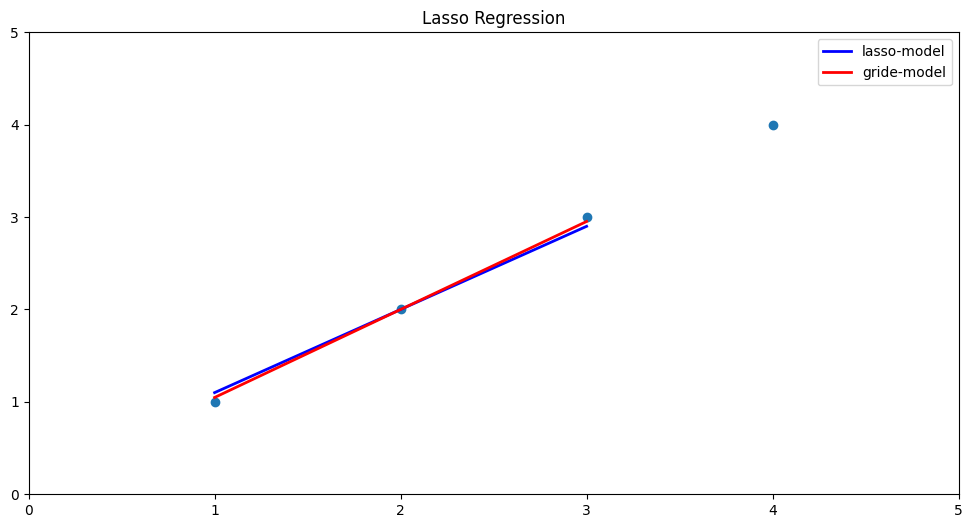

In [ ]:
plt.figure(figsize = (12, 6))

plt.scatter(X, y)
plt.plot(y_train, y_train_pred_lasso, c = 'b', linewidth = 2, label = 'lasso-model')
plt.plot(y_train, y_train_pred_ridge, c = 'r', linewidth = 2, label = 'gride-model')

plt.xlim(xmin = 0, xmax = 5)
plt.ylim(ymin = 0, ymax = 5)
plt.title("Lasso Regression")
plt.legend()
plt.show()